### IMPORTS DE LIBRERIAS Y CARGA DE DATOS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/server_logs.csv')

### ANALISIS DE DATOS PREVIO

In [2]:
#cambiamos a tipo datetime sino pandas lo trataría como string
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

#verificamos el rango de fecha de los logs
rango = pd.DataFrame({
    'rango-fechas': [df['timestamp_event'].min(), df['timestamp_event'].max()]
}, index=['Desde', 'Hasta'])

display(rango)

#columna booleana donde se almacenan los eventos graves entre severidades y status_code
df['is_bad'] = (
    (df['severity'].isin(['ERROR', 'CRITICAL'])) |
    (df['status_code'] >= 500)
)

resumen_general = pd.DataFrame({
    'cantidad-logs': [len(df), df['is_bad'].sum(), round(df['is_bad'].mean() * 100, 2)]
}, index=['Total eventos', 'Eventos malos', 'Bad rate global (%)'])

display(resumen_general)
#captura la cantidad de logs por severidad
display(df['severity'].value_counts().to_frame('cantidad-severidad'))

#captura cantidad de logs por servicio
conteo_servicios = df['service_name'].value_counts().to_frame('cantidad-servicio')
display(conteo_servicios.head(6)) #muestra los primeros 6

#captura cantidad de mensajes
display(df['message'].value_counts().head().to_frame('cantidad-mensaje-general'))
#captura la cantidad de mensajes negativos 
display(df[df['is_bad']]['message'].value_counts().head().to_frame('cantidad-mensaje-malos'))

,rango-fechas
Desde,2026-01-10 00:02:39.029160+00:00
Hasta,2026-01-12 23:59:23.187914+00:00


,cantidad-logs
Total eventos,5795.00
Eventos malos,895.00
Bad rate global (%),15.44


,cantidad-severidad
severity,
INFO,3542
WARN,1358
ERROR,775
CRITICAL,120


,cantidad-servicio
service_name,
api-gateway,1509
orders-service,1057
inventory-service,964
payment-service,842
auth-service,778
notification-service,645


,cantidad-mensaje-general
message,
Health check OK,1196
Background job completed,1185
Request completed,1161
Order creation failed - inventory lock timeout,197
Rate limit nearing threshold,193


,cantidad-mensaje-malos
message,
Order creation failed - inventory lock timeout,197
Payment gateway unavailable,103
Database deadlock detected,99
Checkout failed - upstream payment timeout,88
Possible credential stuffing detected,69


### DETECCION DEL MOMENTO CRITICO (VENTANAS DE 5 MINUTOS) 

In [3]:
#crear bins - intervalos de 5 minutos
df['window'] = df['timestamp_event'].dt.floor('5min')

#agrupar por intervalo contando los eventos totales y su suma 
resumen = df.groupby('window').agg(
    total_events = ('is_bad', 'count'),
    bad_events   = ('is_bad', 'sum')
).reset_index()

#calcular bad_rate por ventana
resumen['bad_rate'] = resumen['bad_events'] / resumen['total_events']

#filtro obligatorio: ventanas con al menos 20 eventos
resumen_filtrado = resumen[resumen['total_events'] >= 20].copy()

#top 5 por bad_rate
top5 = resumen_filtrado.sort_values('bad_rate', ascending=False).head(5)
top5['bad_rate'] = top5['bad_rate'].round(4)

display(top5)

,window,total_events,bad_events,bad_rate
134,2026-01-10 11:10:00+00:00,189,110,0.5820
135,2026-01-10 11:15:00+00:00,228,129,0.5658
136,2026-01-10 11:20:00+00:00,111,59,0.5315
462,2026-01-11 14:35:00+00:00,255,117,0.4588
461,2026-01-11 14:30:00+00:00,156,68,0.4359


### IDENTIFICAR EL MOMENTO CRITICO

In [5]:
#el momento critico es el top 1 del resumen filtrado
momento_critico = resumen_filtrado.sort_values('bad_rate', ascending=False).iloc[0]
ventana_critica = momento_critico['window']

resumen_critico = pd.DataFrame({
    'valor': [
        ventana_critica,
        momento_critico['total_events'],
        momento_critico['bad_events'],
        round(momento_critico['bad_rate'] * 100, 2)
    ]
}, index=['Ventana', 'Total eventos', 'Bad events', 'Bad rate (%)'])

print("MOMENTO CRITICO DETECTADO:")
display(resumen_critico)

MOMENTO CRITICO DETECTADO:


,valor
Ventana,2026-01-10 11:10:00+00:00
Total eventos,189
Bad events,110
Bad rate (%),58.2


### FILTRAR LOS EVENTOS DEL MOMENTO CRITICO

In [6]:
#filtramos solo los eventos que cayeron en la ventana crítica
df_critico = df[df['window'] == ventana_critica].copy()

print("Eventos en la ventana crítica:", len(df_critico))
print("Bad events en la ventana crítica:", df_critico['is_bad'].sum())

Eventos en la ventana crítica: 189
Bad events en la ventana crítica: 110


### BAD EVENTS POR SERVICIO DENTRO DE VENTANA CRITICA

In [7]:
#criterio cantidad de bad events por servicio
bad_por_servicio = (
    df_critico[df_critico['is_bad']]
    .groupby('service_name')
    .size()
    .reset_index(name='bad_events')
    .sort_values('bad_events', ascending=False)
)

print("Bad events por servicio en el momento critico:")
display(bad_por_servicio)

Bad events por servicio en el momento critico:


,service_name,bad_events
1,orders-service,72
0,inventory-service,37
2,payment-service,1


### TOP 5 MENSAJES MAS FRECUENTES EN VENTANA CRITICA

In [8]:
top_mensajes = (
    df_critico[df_critico['is_bad']]['message']
    .value_counts()
    .head(5)
    .to_frame('cantidad')
)

print("top 5 mensajes en bad events:")
display(top_mensajes)

top 5 mensajes en bad events:


,cantidad
message,
Order creation failed - inventory lock timeout,72
Database deadlock detected,37
External dependency error,1


### TOP 5 ENDPOINTS MAS COMPROMETIDOS EN VENTANA CRITICA

In [9]:
#criterio: cantidad de bad events por endpoint
print("criterio: cantidad de bad events por endpoint")

top_endpoints = (
    df_critico[df_critico['is_bad']]
    .groupby('endpoint')
    .size()
    .reset_index(name='bad_events')
    .sort_values('bad_events', ascending=False)
    .head(5)
)

display(top_endpoints)

criterio: cantidad de bad events por endpoint


,endpoint,bad_events
3,/orders/cancel,26
4,/orders/create,25
5,/orders/status,21
1,/inv/reserve,18
2,/inv/stock,13


### SEPERAR INCIDENTE Y BASELINE

In [10]:
# Incidente = la ventana crítica
df_incidente = df[df['window'] == ventana_critica].copy()

# Baseline = todo lo que NO es la ventana crítica
df_baseline = df[df['window'] != ventana_critica].copy()

print("Eventos incidente:", len(df_incidente))
print("Eventos baseline:", len(df_baseline))

Eventos incidente: 189
Eventos baseline: 5606


### TABLA COMPARATIVA

In [13]:
def metricas(subset, nombre):
    return {
        'periodo'        : nombre,
        'total_events'   : len(subset),
        'bad_rate (%)'   : round(subset['is_bad'].mean() * 100, 2),
        'avg_latency_ms' : round(subset['latency_ms'].mean(), 1),
        'pct_5xx (%)'    : round((subset['status_code'] >= 500).mean() * 100, 2)
    }

comparacion = pd.DataFrame([
    metricas(df_incidente, 'Incidente'),
    metricas(df_baseline,  'Baseline')
])

display(comparacion)

,periodo,total_events,bad_rate (%),avg_latency_ms,pct_5xx (%)
0,Incidente,189,58.2,1589.7,58.2
1,Baseline,5606,14.0,521.1,14.0


### EVENTOS POR SEVERIDAD EN EL TIEMPO

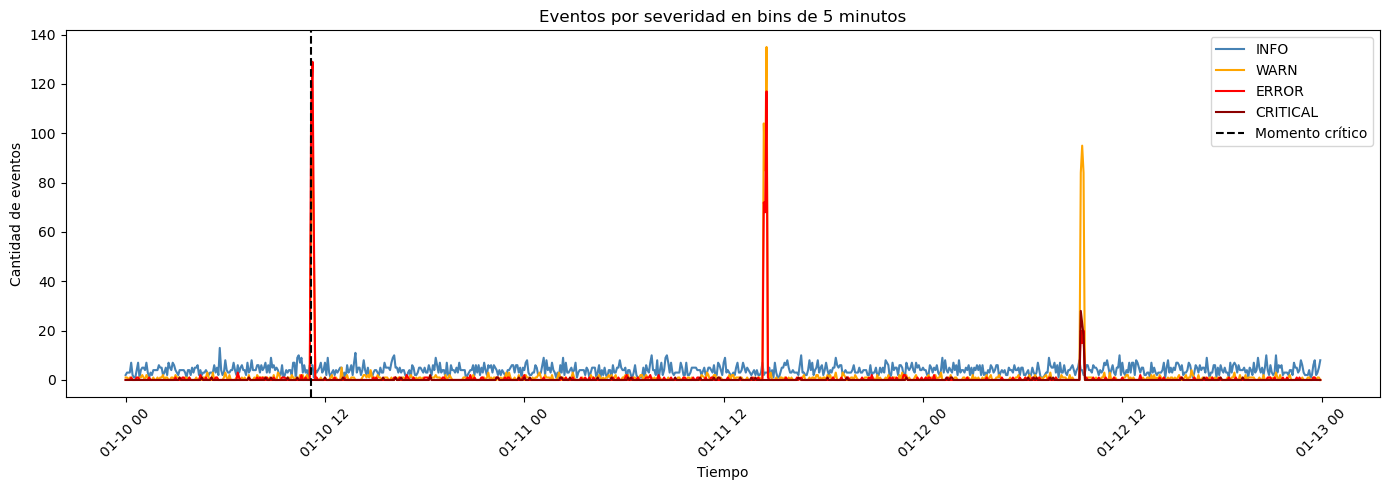

In [12]:
severidades = ['INFO', 'WARN', 'ERROR', 'CRITICAL']
colores     = ['steelblue', 'orange', 'red', 'darkred']

#agrupamos por ventana y severidad
pivot = (
    df.groupby(['window', 'severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=severidades, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))

for sev, color in zip(severidades, colores):
    ax.plot(pivot.index, pivot[sev], label=sev, color=color, linewidth=1.5)

#linea vertical marcando el momento crítico
ax.axvline(x=ventana_critica, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

ax.set_title('Eventos por severidad en bins de 5 minutos')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Cantidad de eventos')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### BAD RATE EN EL TIEMPO

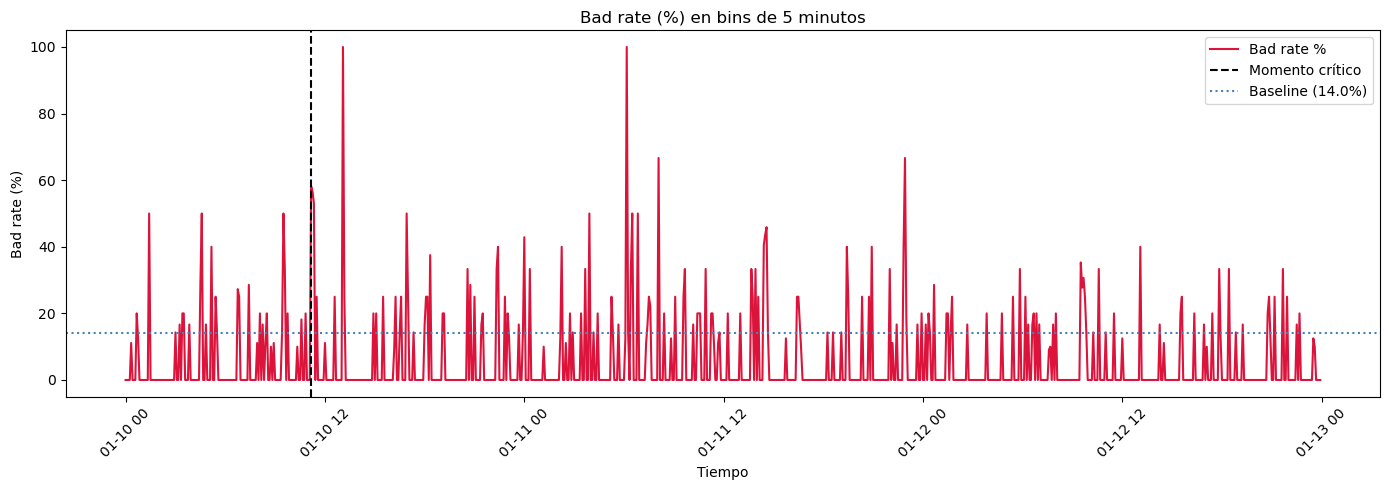

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(resumen['window'], resumen['bad_rate'] * 100,
        color='crimson', linewidth=1.5, label='Bad rate %')

#linea vertical del momento critico
ax.axvline(x=ventana_critica, color='black', linestyle='--', linewidth=1.5, label='Momento crítico')

#linea horizontal del baseline
baseline_rate = round(df_baseline['is_bad'].mean() * 100, 2)
ax.axhline(y=baseline_rate, color='steelblue', linestyle=':', linewidth=1.5,
           label=f'Baseline ({baseline_rate}%)')

ax.set_title('Bad rate (%) en bins de 5 minutos')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Bad rate (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusiones

El momento crítico ocurrió el 2026-01-10 entre las 11:10 y las 11:15 UTC,
con 189 eventos registrados y un bad rate de 58.2% — más de la mitad del
tráfico fallando en esa ventana.

El servicio más afectado fue orders-service con 72 bad events, seguido por
inventory-service con 37. El endpoint más comprometido fue /orders/cancel
con 26 bad events, aunque /orders/create y /orders/status también superaron
los 20 bad events cada uno.

El mensaje dominante fue "Order creation failed - inventory lock timeout"
(72 ocurrencias), acompañado de "Database deadlock detected" (37 ocurrencias),
lo que sugiere una falla en cadena entre el servicio de órdenes y el inventario.

Comparado con el baseline, el bad rate se multiplicó por 4 (58.2% vs 14.0%)
y la latencia promedio se triplicó (1589.7ms vs 521.1ms), confirmando una
degradación severa y concentrada en el flujo de creación y gestión de órdenes.